In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from ipywidgets import Button, HBox, VBox, Label, IntText, Output
import tifffile as tiff
import os

In [10]:
### New version
class CellLabeler:
    def __init__(self, features_df, image_paths, mask_paths):
        self.df = features_df.copy()
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.current_idx = 0
        self.labels = np.full(len(self.df), -1, dtype=int)  # -1 = unlabeled
        
        # Create widgets
        self.img_output = Output()
        self.label_buttons = HBox([
            Button(description='Healthy (0)', button_style='success'),
            Button(description='Unhealthy (1)', button_style='danger'),
            Button(description='Mitotic (2)', button_style='info'),
            Button(description='Weird (3)', button_style='primary'),
            Button(description='Unsure (Skip)', button_style='warning')
        ])
        self.counter = IntText(value=0, description='Labeled:')
        self.progress = Label(f"Progress: 0/{len(self.df)}")
        
        # Set up callbacks
        self.label_buttons.children[0].on_click(self._label_healthy)
        self.label_buttons.children[1].on_click(self._label_unhealthy)
        self.label_buttons.children[2].on_click(self._label_mitotic)
        self.label_buttons.children[3].on_click(self._label_weird)
        self.label_buttons.children[4].on_click(self._next_cell)
        
        # Display initial cell
        self._show_current_cell()

    def _show_current_cell(self):
        with self.img_output:
            clear_output(wait=True)
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
            
            # Load raw image (handle 3D stacks)
            img = tiff.imread(self.image_paths[self.current_idx])
            if img.ndim == 3:  # If multi-page TIFF
                img = img[0]  # Take first slice, or use img.max(axis=0)
            ax1.imshow(img.squeeze(), cmap='gray')  # Remove singleton dimensions
            ax1.set_title(f"Cell {self.current_idx} - Raw Image")
            
            # Load mask (handle label matrices)
            mask = tiff.imread(self.mask_paths[self.current_idx])
            if mask.ndim == 3:  # If multi-page TIFF
                mask = mask[0]
            
            # Convert label matrix to binary (optional)
            binary_mask = (mask > 0).astype(np.uint8)
            
            ax2.imshow(mask.squeeze(), cmap='viridis', vmin=0, vmax=mask.max())
            ax2.set_title("Segmentation Mask (Track IDs)")
            
            plt.show()
            display(self.df.iloc[self.current_idx].to_frame().T)

    def _update_label(self, label):
        self.labels[self.current_idx] = label
        self.counter.value = sum(self.labels != -1)
        self.progress.value = f"Progress: {self.counter.value}/{len(self.df)}"
        self._next_cell()
        
    def _label_healthy(self, btn):
        self._update_label(0)
        
    def _label_unhealthy(self, btn):
        self._update_label(1)
        
    def _label_mitotic(self, btn):
        self._update_label(2)
        
    def _label_weird(self, btn):
        self._update_label(3)
        
    def _next_cell(self, btn=None):
        self.current_idx = (self.current_idx + 1) % len(self.df)
        self._show_current_cell()
        
    def show(self):
        display(VBox([self.img_output, self.label_buttons, self.counter, self.progress]))
        
    def get_labels(self):
        return self.labels

def structured_sort_key(filepath):
    filename = os.path.splitext(os.path.basename(filepath))[0]
    parts = filename.split('_')
    
    # Extract numbers from relevant parts
    exp_num = int(parts[1][3:])    # Extract from "ExpXX"
    site_num = int(parts[2][4:])   # Extract from "SiteXX"
    seq_num = int(float(parts[3]))       # Trailing number
    
    return (exp_num, site_num, seq_num)

In [3]:
class CellLabeler:
    def __init__(self, features_df, image_paths, mask_paths):
        self.df = features_df.copy()
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.current_idx = 0
        self.labels = np.full(len(self.df), -1, dtype=int)  # -1 = unlabeled
        
        # Create widgets
        self.img_output = Output()
        self.label_buttons = HBox([
            Button(description='Healthy (0)', button_style='success'),
            Button(description='Unhealthy (1)', button_style='danger'),
            Button(description='Unsure (Skip)', button_style='warning')
        ])
        self.counter = IntText(value=0, description='Labeled:')
        self.progress = Label(f"Progress: 0/{len(self.df)}")
        
        # Set up callbacks
        self.label_buttons.children[0].on_click(self._label_healthy)
        self.label_buttons.children[1].on_click(self._label_unhealthy)
        self.label_buttons.children[2].on_click(self._next_cell)
        
        # Display initial cell
        self._show_current_cell()

    def _show_current_cell(self):
        with self.img_output:
            clear_output(wait=True)
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
            
            # Load raw image (handle 3D stacks)
            img = tiff.imread(self.image_paths[self.current_idx])
            if img.ndim == 3:  # If multi-page TIFF
                img = img[0]  # Take first slice, or use img.max(axis=0)
            ax1.imshow(img.squeeze(), cmap='gray')  # Remove singleton dimensions
            ax1.set_title(f"Cell {self.current_idx} - Raw Image")
            
            # Load mask (handle label matrices)
            mask = tiff.imread(self.mask_paths[self.current_idx])
            if mask.ndim == 3:  # If multi-page TIFF
                mask = mask[0]
            
            # Convert label matrix to binary (optional)
            binary_mask = (mask > 0).astype(np.uint8)
            
            ax2.imshow(mask.squeeze(), cmap='viridis', vmin=0, vmax=mask.max())
            ax2.set_title("Segmentation Mask (Track IDs)")
            
            plt.show()
            display(self.df.iloc[self.current_idx].to_frame().T)

            
    def _update_label(self, label):
        self.labels[self.current_idx] = label
        self.counter.value = sum(self.labels != -1)
        self.progress.value = f"Progress: {self.counter.value}/{len(self.df)}"
        self._next_cell()
        
    def _label_healthy(self, btn):
        self._update_label(0)
        
    def _label_unhealthy(self, btn):
        self._update_label(1)
        
    def _next_cell(self, btn=None):
        self.current_idx = (self.current_idx + 1) % len(self.df)
        self._show_current_cell()
        
    def show(self):
        display(VBox([self.img_output, self.label_buttons, self.counter, self.progress]))
        
    def get_labels(self):
        return self.labels



In [11]:
features_df = pd.read_csv("/home/nbahou/myimaging/apoDet/data/dataset1/features_df/features.csv")

In [12]:
filenames = features_df['filename']

In [13]:
filtered_df = features_df[features_df['filename'].str.startswith('cell_Exp09_Site14_')]

In [14]:
filtered_df

,Unnamed: 0,label,eccentricity,intensity_mean,intensity_std,solidity,x,y,t,filename
70489,70489,1.0,0.621354,3212.046119,487.036806,0.960706,224.0,666.0,0.0,cell_Exp09_Site14_1.tif
70490,70490,3.0,0.631740,4719.292567,1120.886494,0.954745,90.0,670.0,0.0,cell_Exp09_Site14_3.tif
70491,70491,4.0,0.820129,3097.122873,576.038547,0.949870,396.0,674.0,0.0,cell_Exp09_Site14_4.tif
70492,70492,5.0,0.588702,4649.522655,967.178001,0.966569,902.0,670.0,0.0,cell_Exp09_Site14_5.tif
70493,70493,6.0,0.675522,3321.948423,615.399130,0.958658,742.0,666.0,0.0,cell_Exp09_Site14_6.tif
...,...,...,...,...,...,...,...,...,...,...
71878,71878,7490.0,0.785549,2412.648290,542.019173,0.902640,344.0,702.0,1404.0,cell_Exp09_Site14_7490.tif
71879,71879,7507.0,0.615282,3845.050844,875.890938,0.944402,508.0,738.0,1409.0,cell_Exp09_Site14_7507.tif
71880,71880,7519.0,0.517402,3690.802437,902.901185,0.948816,516.0,564.0,1414.0,cell_Exp09_Site14_7519.tif
71881,71881,7540.0,0.601265,3369.704765,931.817659,0.954771,32.0,524.0,1421.0,cell_Exp09_Site14_7540.tif


In [15]:
# Usage example
BASE_DIR = '/home/nbahou/myimaging/apoDet/data/dataset1/features_df'
features_df = pd.read_csv('/home/nbahou/myimaging/apoDet/data/dataset1/features_df/features.csv')  # From previous analysis
image_paths = sorted(
    [os.path.join(BASE_DIR, "raw_images", f) 
     for f in os.listdir(f"{BASE_DIR}/raw_images")],
    key=structured_sort_key
)
filtered_paths = [
    path for path in image_paths 
    if os.path.basename(path).startswith('cell_Exp09_Site14_')
]
mask_paths = sorted(
    [os.path.join(BASE_DIR, "masks", f) 
     for f in os.listdir(f"{BASE_DIR}/masks")],
    key=structured_sort_key
)
filtered_mask_paths = [
    path for path in mask_paths 
    if os.path.basename(path).startswith('cell_Exp09_Site14_')
]



labeler = CellLabeler(filtered_df, filtered_paths, filtered_mask_paths)
labeler.show()

In [14]:
int('3683.0')

ValueError: invalid literal for int() with base 10: '3683.0'

In [9]:
# Usage example
BASE_DIR = '/home/nbahou/myimaging/apoDet/data/test_health_filter/features_df'
features_df = pd.read_csv("/home/nbahou/myimaging/apoDet/data/test_health_filter/features_df/features.csv")  # From previous analysis
image_paths = sorted([os.path.join(BASE_DIR, "raw_images", f) for f in os.listdir(f"{BASE_DIR}/raw_images")])
mask_paths = sorted([os.path.join(BASE_DIR, "masks", f) for f in os.listdir(f"{BASE_DIR}/masks")])

labeler = CellLabeler(features_df, image_paths, mask_paths)
labeler.show()

In [17]:
labels = labeler.get_labels()
print(labels)
labeled_df = filtered_df[['label', 'x', 'y', 't', 'filename']].copy()
labeled_df['status'] = labels
print(labeled_df)

[ 0  0  0 ... -1  1  1]
        label      x      y       t                    filename  status
70489     1.0  224.0  666.0     0.0     cell_Exp09_Site14_1.tif       0
70490     3.0   90.0  670.0     0.0     cell_Exp09_Site14_3.tif       0
70491     4.0  396.0  674.0     0.0     cell_Exp09_Site14_4.tif       0
70492     5.0  902.0  670.0     0.0     cell_Exp09_Site14_5.tif       0
70493     6.0  742.0  666.0     0.0     cell_Exp09_Site14_6.tif       0
...       ...    ...    ...     ...                         ...     ...
71878  7490.0  344.0  702.0  1404.0  cell_Exp09_Site14_7490.tif       0
71879  7507.0  508.0  738.0  1409.0  cell_Exp09_Site14_7507.tif      -1
71880  7519.0  516.0  564.0  1414.0  cell_Exp09_Site14_7519.tif      -1
71881  7540.0   32.0  524.0  1421.0  cell_Exp09_Site14_7540.tif       1
71882  7547.0  232.0  700.0  1423.0  cell_Exp09_Site14_7547.tif       1

[1394 rows x 6 columns]


In [18]:
clean_labels = labeled_df[labeled_df['status'] != -1]

In [19]:
print(clean_labels[clean_labels['status'] != -1])

        label      x      y       t                    filename  status
70489     1.0  224.0  666.0     0.0     cell_Exp09_Site14_1.tif       0
70490     3.0   90.0  670.0     0.0     cell_Exp09_Site14_3.tif       0
70491     4.0  396.0  674.0     0.0     cell_Exp09_Site14_4.tif       0
70492     5.0  902.0  670.0     0.0     cell_Exp09_Site14_5.tif       0
70493     6.0  742.0  666.0     0.0     cell_Exp09_Site14_6.tif       0
...       ...    ...    ...     ...                         ...     ...
71873  7398.0   46.0   46.0  1375.0  cell_Exp09_Site14_7398.tif       0
71876  7434.0  184.0  716.0  1388.0  cell_Exp09_Site14_7434.tif       3
71878  7490.0  344.0  702.0  1404.0  cell_Exp09_Site14_7490.tif       0
71881  7540.0   32.0  524.0  1421.0  cell_Exp09_Site14_7540.tif       1
71882  7547.0  232.0  700.0  1423.0  cell_Exp09_Site14_7547.tif       1

[1053 rows x 6 columns]


In [20]:
import os
import tifffile as tiff
import pandas as pd
from skimage.measure import regionprops_table

# Configuration
PROPERTIES = [
    'area', 'perimeter', 'bbox_area', 'convex_area', 'eccentricity',
    'equivalent_diameter', 'extent', 'feret_diameter_max', 'major_axis_length',
    'minor_axis_length', 'orientation', 'solidity', 'intensity_mean',
    'intensity_std', 'intensity_max', 'intensity_min', 'moments_hu'
]

# Initialize list to store features
features_list = []

# Iterate through annotated cells
for idx, row in labeled_df.iterrows():
    # Load mask and image
    mask_path = os.path.join(BASE_DIR, "masks", row['filename'])
    img_path = os.path.join(BASE_DIR, "raw_images", row['filename'])
    
    masks = tiff.imread(mask_path)
    imgs = tiff.imread(img_path)

    current_features = []
    for mask, img in zip(masks,imgs):    
        # Calculate features (KEY FIX: use mask/img variables)
        features = regionprops_table(
            label_image=mask.astype(int),  # Ensure integer type
            intensity_image=img,
            properties=PROPERTIES
        )
        feature_df = pd.DataFrame(features)
        if not feature_df.empty:
            current_features.append(feature_df)

    if current_features:
        current_features_df = pd.concat(current_features, ignore_index=True)
        mean_features = current_features_df.mean()
        features_list.append(mean_features)
    

# Convert to DataFrame and merge
features_df = pd.DataFrame(features_list)
final_df = pd.concat([labeled_df.reset_index(drop=True), 
                     features_df.reset_index(drop=True)], axis=1)

final_df.to_csv("/home/nbahou/myimaging/apoDet/data/dataset1/features_df/labeled_cells_09_14.csv", index=False)


# Verify
print(f"Original rows: {len(labeled_df)}")
print(f"New features: {features_df.shape}")
print(final_df.head())

Original rows: 1394
New features: (1394, 23)
   label      x      y    t                 filename  status   area  \
0    1.0  224.0  666.0  0.0  cell_Exp09_Site14_1.tif       0  446.2   
1    3.0   90.0  670.0  0.0  cell_Exp09_Site14_3.tif       0  291.6   
2    4.0  396.0  674.0  0.0  cell_Exp09_Site14_4.tif       0  395.4   
3    5.0  902.0  670.0  0.0  cell_Exp09_Site14_5.tif       0  490.8   
4    6.0  742.0  666.0  0.0  cell_Exp09_Site14_6.tif       0  306.4   

   perimeter  bbox_area  convex_area  ...  intensity_std  intensity_max  \
0  78.458283      580.8        463.8  ...     482.315691         4216.8   
1  62.829856      396.0        304.2  ...    1120.503537         7651.2   
2  76.555339      557.4        415.0  ...     566.994781         4348.0   
3  81.266609      631.0        508.8  ...     976.913573         6407.2   
4  64.547013      409.6        320.0  ...     625.896153         4542.4   

   intensity_min  moments_hu-0  moments_hu-1  moments_hu-2  moments_hu-3  \
0

In [4]:
# With additional options
df = pd.read_csv('/home/nbahou/myimaging/apoDet/data/test_health_filter/features_df/labeled_cells.csv', 
                 sep=',',           # specify separator 
                 header=0,           # use first row as column names
                 index_col=None)     # optional: specify index column


final_df = df[df['status'] != -1]

In [21]:
final_df

,label,x,y,t,filename,status,area,perimeter,bbox_area,convex_area,...,intensity_std,intensity_max,intensity_min,moments_hu-0,moments_hu-1,moments_hu-2,moments_hu-3,moments_hu-4,moments_hu-5,moments_hu-6
0,1.0,224.0,666.0,0.0,cell_Exp09_Site14_1.tif,0,446.2,78.458283,580.8,463.8,...,482.315691,4216.8,1684.8,0.165663,0.001596,0.000084,1.157264e-06,-5.193226e-12,-3.318590e-08,-1.460641e-11
1,3.0,90.0,670.0,0.0,cell_Exp09_Site14_3.tif,0,291.6,62.829856,396.0,304.2,...,1120.503537,7651.2,2157.0,0.165619,0.001542,0.000140,2.926987e-06,2.752219e-11,4.163183e-08,-6.663255e-11
2,4.0,396.0,674.0,0.0,cell_Exp09_Site14_4.tif,0,395.4,76.555339,557.4,415.0,...,566.994781,4348.0,1477.2,0.186553,0.009022,0.000076,7.014237e-06,7.550943e-11,1.269744e-07,-1.602395e-10
3,5.0,902.0,670.0,0.0,cell_Exp09_Site14_5.tif,0,490.8,81.266609,631.0,508.8,...,976.913573,6407.2,2412.8,0.162879,0.001146,0.000010,1.349768e-07,5.099696e-14,1.105798e-09,-1.572564e-13
4,6.0,742.0,666.0,0.0,cell_Exp09_Site14_6.tif,0,306.4,64.547013,409.6,320.0,...,625.896153,4542.4,1559.4,0.167334,0.002360,0.000077,1.776849e-06,-1.759626e-11,-7.313600e-08,1.555047e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389,7490.0,344.0,702.0,1404.0,cell_Exp09_Site14_7490.tif,0,300.4,70.526912,464.0,333.8,...,519.148628,3511.8,1234.8,0.198072,0.010519,0.000765,4.452790e-05,-4.140443e-09,-2.066340e-06,2.243353e-09
1390,7507.0,508.0,738.0,1409.0,cell_Exp09_Site14_7507.tif,-1,231.6,57.007316,299.8,244.8,...,843.037946,5420.8,1595.0,0.165447,0.001439,0.000047,2.123917e-06,6.507738e-11,9.640995e-08,-2.323223e-12
1391,7519.0,516.0,564.0,1414.0,cell_Exp09_Site14_7519.tif,-1,479.8,83.809755,626.2,513.8,...,901.878474,5995.8,1347.8,0.173159,0.003100,0.000392,4.108281e-05,1.023051e-08,4.218867e-07,1.673789e-08
1392,7540.0,32.0,524.0,1421.0,cell_Exp09_Site14_7540.tif,1,274.4,61.201429,366.2,288.0,...,941.620540,5641.4,1582.8,0.165492,0.001236,0.000191,2.103850e-06,-3.591567e-11,-9.751530e-09,-4.325839e-11


In [22]:
from sklearn.feature_selection import f_classif

final_df_filt = final_df[final_df['status'] != -1]

X = final_df_filt.drop(columns=['label', 'filename', 'status'])  # Features
y = final_df_filt['status']  # Labels (0=healthy, 1=unhealthy)

# Calculate ANOVA F-values
f_scores, p_values = f_classif(X, y)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values('F_score', ascending=False)

print(feature_importance.head(10))

              Feature    F_score       p_value
2                   t  89.164742  1.714241e-36
14           solidity  23.017204  1.646960e-10
16      intensity_std  22.381448  3.029323e-10
21       moments_hu-2  19.537395  4.667526e-09
22       moments_hu-3  12.532636  4.179213e-06
17      intensity_max   9.021878  1.303566e-04
12  minor_axis_length   8.576496  2.020095e-04
7        eccentricity   7.985326  3.615155e-04
6         convex_area   5.437540  4.473545e-03
3                area   5.331430  4.968976e-03


In [23]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y)
feature_importance['MI_score'] = mi_scores
feature_importance = feature_importance.sort_values('MI_score', ascending=False)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

feature_importance['RF_importance'] = model.feature_importances_
feature_importance = feature_importance.sort_values('RF_importance', ascending=False)

In [25]:
print(feature_importance)

                Feature    F_score       p_value  MI_score  RF_importance
7          eccentricity   7.985326  3.615155e-04  0.022571       0.096180
11    major_axis_length   0.937363  3.919869e-01  0.000000       0.062692
5             bbox_area   4.627243  9.982013e-03  0.005321       0.060030
6           convex_area   5.437540  4.473545e-03  0.002354       0.059381
1                     y   1.647486  1.930307e-01  0.001486       0.053508
25         moments_hu-6   1.836502  1.598854e-01  0.006884       0.047044
9                extent   3.784616  2.302809e-02  0.036365       0.042136
18        intensity_min   4.717230  9.130239e-03  0.000000       0.040520
14             solidity  23.017204  1.646960e-10  0.000000       0.039171
15       intensity_mean   3.231820  3.987869e-02  0.013569       0.033644
20         moments_hu-1   4.149749  1.602774e-02  0.009339       0.032871
8   equivalent_diameter   4.694917  9.334404e-03  0.000000       0.032363
17        intensity_max   9.021878  1.

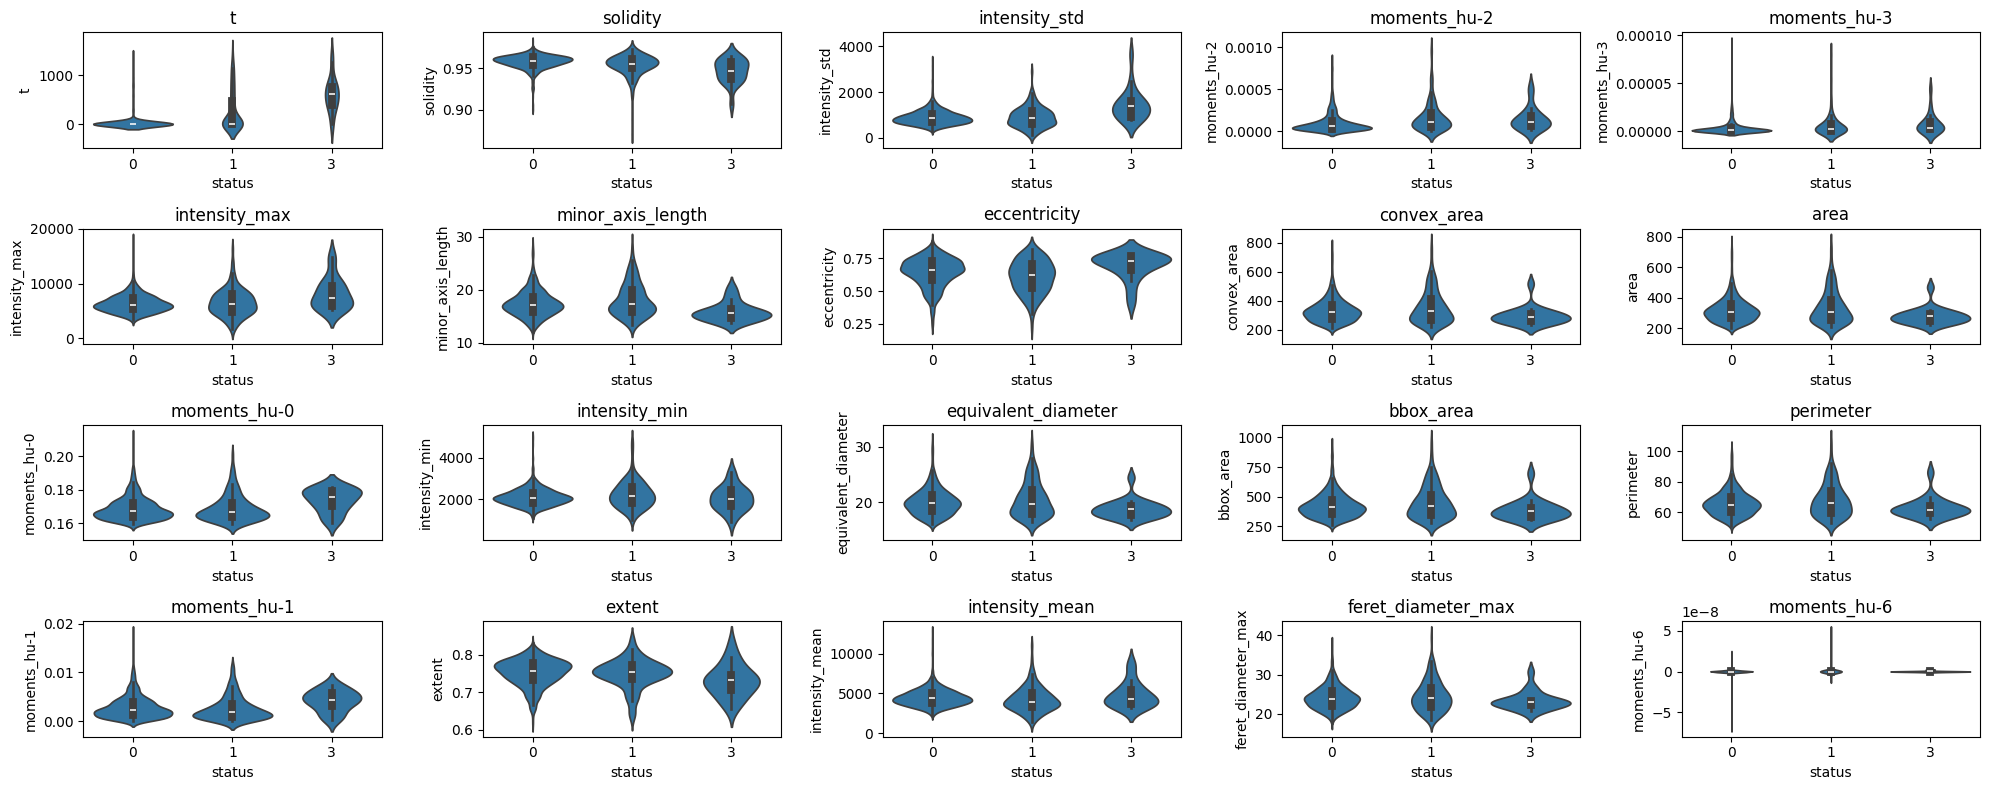

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values('F_score', ascending=False)

top_features = feature_importance.head(20)['Feature'].tolist()  # Get top 10 features

fig, axes = plt.subplots(4, 5, figsize=(20, 8))  # Create a 2-row, 5-column grid
axes = axes.flatten()  # Flatten axes array for easy iteration

for ax, feat in zip(axes, top_features):
    sns.violinplot(x='status', y=feat, data=final_df_filt, ax=ax)
    ax.set_title(feat)

plt.tight_layout()
plt.show()

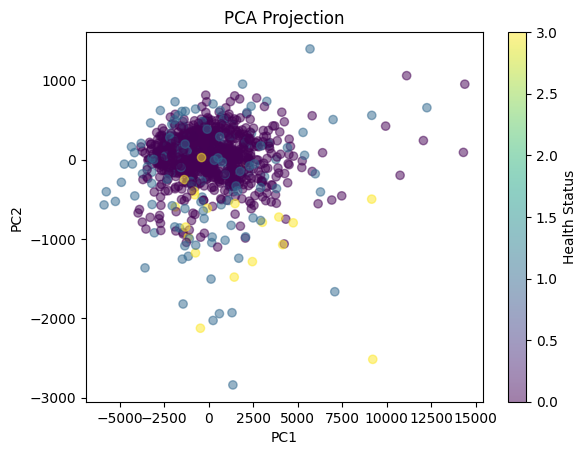

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection')
plt.colorbar(label='Health Status')

Text(0.5, 1.0, 'Feature Correlation Matrix')

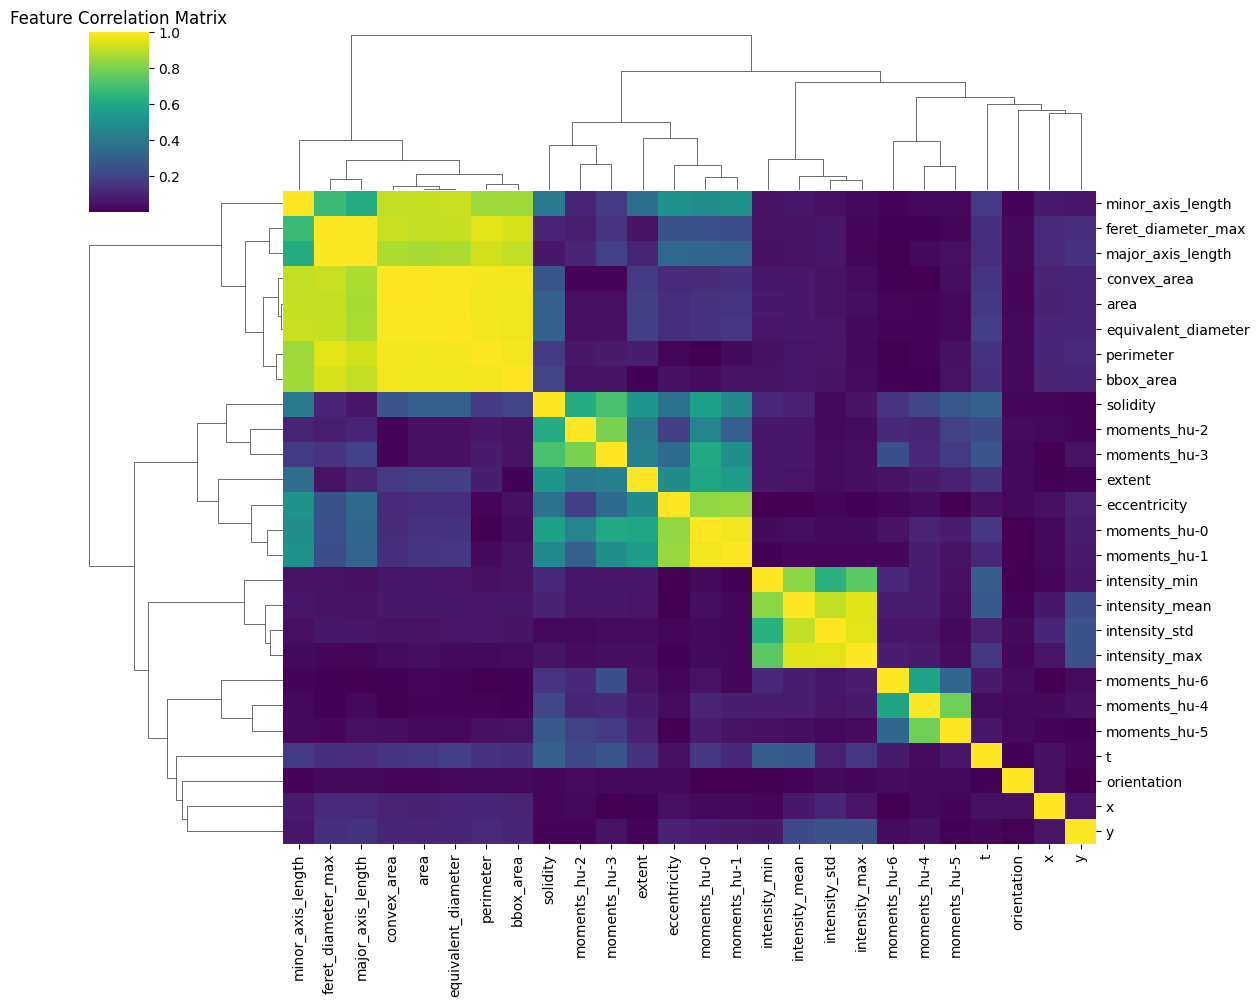

In [28]:
corr_matrix = X.corr()
sns.clustermap(corr_matrix.abs(), cmap='viridis', figsize=(12, 10))
plt.title('Feature Correlation Matrix')

In [15]:
print(feature_importance)

                Feature   F_score   p_value  MI_score  RF_importance
3                  area  3.453163  0.063450  0.000977       0.049383
7          eccentricity  0.000529  0.981663  0.022841       0.046413
11    major_axis_length  4.486094  0.034439  0.002996       0.046263
8   equivalent_diameter  3.858839  0.049785  0.000000       0.045291
10   feret_diameter_max  4.061605  0.044159  0.023436       0.045144
24         moments_hu-5  0.804531  0.369976  0.024687       0.044185
15       intensity_mean  0.057013  0.811335  0.000133       0.044114
14             solidity  0.173325  0.677270  0.000000       0.043374
23         moments_hu-4  0.890715  0.345531  0.000000       0.042512
9                extent  1.025115  0.311575  0.000000       0.041938
13          orientation  0.072269  0.788121  0.000000       0.041478
25         moments_hu-6  0.566650  0.451786  0.000000       0.041270
6           convex_area  3.626918  0.057163  0.000000       0.040013
19         moments_hu-0  0.063975 

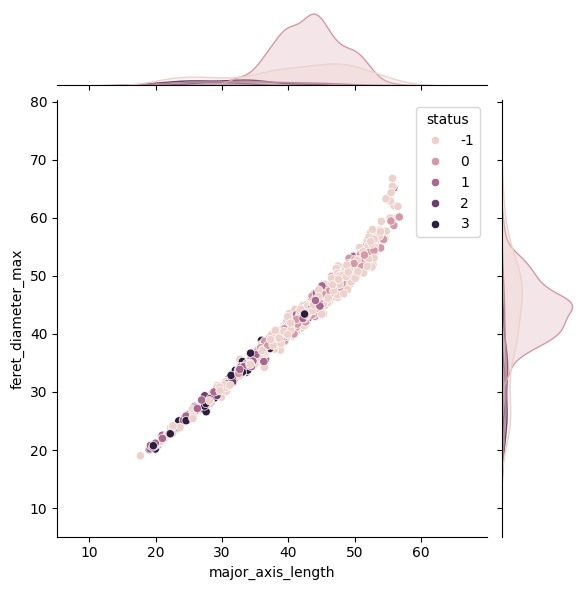

In [43]:
sns.jointplot(data=final_df, x='major_axis_length', y='feret_diameter_max', hue='status')

In [16]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBClassifier()
model.fit(X_train, y_train)
print(f"Accuracy: {model.score(X_test, y_test):.2f}")

ModuleNotFoundError: No module named 'xgboost'

In [4]:
import pandas as pd

In [5]:
# With additional options
df = pd.read_csv('/home/nbahou/myimaging/apoDet/data/test_health_filter/features_df/labeled_cells.csv', 
                 sep=',',           # specify separator 
                 header=0,           # use first row as column names
                 index_col=None)     # optional: specify index column

img_dir = '/home/nbahou/myimaging/apoDet/data/test_health_filter/features_df/raw_images'

In [10]:
import os
import shutil

# Define the source directory (where your raw images are) and the destination base folder.
source_dir = '/home/nbahou/myimaging/apoDet/data/test_health_filter/features_df/raw_images'
destination_base = '/home/nbahou/myimaging/apoDet/data/test_health_filter/features_df/raw_imgs_separate'

# Create destination base directory if it doesn't exist.
os.makedirs(destination_base, exist_ok=True)

# Loop over your statuses (for example, -1 to 3; adjust as needed)
for status in range(-1, 4):
    # Create a directory for each status inside the destination base
    status_dir = os.path.join(destination_base, str(status))
    os.makedirs(status_dir, exist_ok=True)

    # Filter the dataframe for the current status
    current_data = df[df['status'] == status]
    print(f"Processing status: {status}")

    for index, row in current_data.iterrows():
        # Assume 'filename' contains the relative or absolute path of the file
        filename = row['filename']
        
        source_file = os.path.join(source_dir, filename)

        # Copy the file to the destination directory
        destination_file = os.path.join(status_dir, filename)
        shutil.copy(source_file, destination_file)


Processing status: -1
Processing status: 0
Processing status: 1
Processing status: 2
Processing status: 3


In [11]:
import os
import shutil

# Define the source directory (where your raw images are) and the destination base folder.
source_dir = '/home/nbahou/myimaging/apoDet/data/test_health_filter/features_df/masks'
destination_base = '/home/nbahou/myimaging/apoDet/data/test_health_filter/features_df/masks_separate'

# Create destination base directory if it doesn't exist.
os.makedirs(destination_base, exist_ok=True)

# Loop over your statuses (for example, -1 to 3; adjust as needed)
for status in range(-1, 4):
    # Create a directory for each status inside the destination base
    status_dir = os.path.join(destination_base, str(status))
    os.makedirs(status_dir, exist_ok=True)

    # Filter the dataframe for the current status
    current_data = df[df['status'] == status]
    print(f"Processing status: {status}")

    for index, row in current_data.iterrows():
        # Assume 'filename' contains the relative or absolute path of the file
        filename = row['filename']
        
        source_file = os.path.join(source_dir, filename)

        # Copy the file to the destination directory
        destination_file = os.path.join(status_dir, filename)
        shutil.copy(source_file, destination_file)


Processing status: -1
Processing status: 0
Processing status: 1
Processing status: 2
Processing status: 3


label      x      y    t                 filename  status   area  \
0    2.0  678.0  688.0  0.0  cell_Exp01_Site01_2.tif      -1  921.8   
1    3.0   70.0  678.0  0.0  cell_Exp01_Site01_3.tif       0  535.8   
2    4.0  282.0  680.0  0.0  cell_Exp01_Site01_4.tif       0  868.4   
3    5.0  106.0  680.0  0.0  cell_Exp01_Site01_5.tif       0  940.0   
4    6.0  400.0  682.0  0.0  cell_Exp01_Site01_6.tif       0  969.2   

In [ ]:
filenames = clean_labels['filename']
features_list = []



for name in filenames:
    mask = tiff.imread(os.path.join(BASE_DIR, "masks", name))
    img = tiff.imread(os.path.join(BASE_DIR, "raw_images", name))

    features = regionprops_table(
        label_image=mask, 
        intensity_image=img,
        properties=PROPERTIES
    )

    features_list.append(features)

features_df = pd.DataFrame(features_list)






In [ ]:
from skimage.measure import regionprops_table



# Get all features for your masks
features = regionprops_table(
    label_image=masks, 
    intensity_image=raw_image,
    properties=PROPERTIES
)
df = pd.DataFrame(features)

In [ ]:
# After labeling
labels = labeler.get_labels()
labeled_df = features_df.copy()
labeled_df['label'] = labels
labeled_df.to_csv("labeled_cells.csv", index=False)

# Filter out skipped cells (-1 labels)
clean_labels = labeled_df[labeled_df['label'] != -1]